# Shot Quality Analysis Handoff

This notebook is the report-facing version of the Week 4 modeling work. It compares the logistic regression baseline against the gradient-boosted shot-quality model on the 2014-15 Kaggle shot log, then turns the boosted model into player and team residual tables that Cole can quote in the Analysis section and Calder can reuse for visuals.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

repo_root = Path.cwd().resolve()
if not (repo_root / 'src').exists():
    for candidate_root in repo_root.parents:
        if (candidate_root / 'src').exists():
            repo_root = candidate_root
            break

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.features.kaggle_shot_quality import (
    CATEGORICAL_FEATURES,
    MODEL_COLUMNS,
    NUMERIC_FEATURES,
    PLAYER_NAME_COLUMN,
    TARGET_COLUMN,
    TEAM_COLUMN,
    build_modeling_frame,
    build_residual_table,
    load_kaggle_shot_logs,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


In [2]:
raw_shots = load_kaggle_shot_logs()
modeling_shots = build_modeling_frame(raw_shots)

print(f'Raw Kaggle rows: {len(raw_shots):,}')
print(f'Modeling rows retained: {len(modeling_shots):,}')
print(f'Missing SHOT_CLOCK values kept for imputation: {int(modeling_shots['SHOT_CLOCK'].isna().sum()):,}')
print(f'Rows above 100K floor: {len(modeling_shots) > 100_000}')


Raw Kaggle rows: 128,069
Modeling rows retained: 128,069
Missing SHOT_CLOCK values kept for imputation: 5,567
Rows above 100K floor: True


In [3]:
model_features = modeling_shots[MODEL_COLUMNS].copy()
shot_outcomes = modeling_shots[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    model_features,
    shot_outcomes,
    test_size=0.2,
    random_state=42,
    stratify=shot_outcomes,
)

logistic_preprocessor = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]),
        NUMERIC_FEATURES,
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]),
        CATEGORICAL_FEATURES,
    ),
])

tree_preprocessor = ColumnTransformer([
    (
        'num',
        Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
        ]),
        NUMERIC_FEATURES,
    ),
    (
        'cat',
        Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]),
        CATEGORICAL_FEATURES,
    ),
])

baseline_model = Pipeline([
    ('preprocessor', logistic_preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs')),
])

boosted_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        reg_lambda=1.0,
        random_state=42,
        tree_method='hist',
        n_jobs=4,
    )),
])


In [4]:
def fit_and_score(model_name, model_pipeline, X_train, X_test, y_train, y_test):
    trained_model = clone(model_pipeline)
    trained_model.fit(X_train, y_train)

    predicted_labels = trained_model.predict(X_test)
    predicted_make_probabilities = trained_model.predict_proba(X_test)[:, 1]

    return {
        'model': model_name,
        'accuracy': accuracy_score(y_test, predicted_labels),
        'roc_auc': roc_auc_score(y_test, predicted_make_probabilities),
        'predicted_make_probabilities': predicted_make_probabilities,
        'trained_model': trained_model,
    }

baseline_results = fit_and_score('logistic_regression', baseline_model, X_train, X_test, y_train, y_test)
boosted_results = fit_and_score('xgboost', boosted_model, X_train, X_test, y_train, y_test)

metric_summary = pd.DataFrame([
    {
        'model': result['model'],
        'accuracy': result['accuracy'],
        'roc_auc': result['roc_auc'],
        'train_rows': len(X_train),
        'test_rows': len(X_test),
        'modeling_rows': len(modeling_shots),
    }
    for result in (baseline_results, boosted_results)
]).sort_values('roc_auc', ascending=False)

metric_summary


,model,accuracy,roc_auc,train_rows,test_rows,modeling_rows
1,xgboost,0.619505,0.643554,102455,25614,128069
0,logistic_regression,0.613258,0.634716,102455,25614,128069


In [5]:
full_season_boosted_model = clone(boosted_model)
full_season_boosted_model.fit(model_features, shot_outcomes)

scored_shots = modeling_shots[[PLAYER_NAME_COLUMN, TEAM_COLUMN, TARGET_COLUMN, 'FGM', 'PTS']].copy()
scored_shots['EXPECTED_MAKE_PROB'] = full_season_boosted_model.predict_proba(model_features)[:, 1]

player_residuals = build_residual_table(scored_shots, PLAYER_NAME_COLUMN, min_shots=150)
team_residuals = build_residual_table(scored_shots, TEAM_COLUMN, min_shots=2000)

print('Top player overperformers')
display(player_residuals.head(10))
print('Top team overperformers')
display(team_residuals.head(10))


Top player overperformers


,player_name,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
0,chris paul,885,425,373.526215,0.480226,0.422064,51.473785,0.058162
1,kyle korver,478,235,189.884323,0.491632,0.397248,45.115677,0.094384
2,nikola vucevic,902,480,439.607605,0.532151,0.487370,40.392395,0.044781
3,stephen curry,968,470,431.557312,0.485537,0.445824,38.442688,0.039714
4,dirk nowtizski,816,377,342.676239,0.462010,0.419946,34.323761,0.042063
5,joe johnson,767,335,301.078308,0.436767,0.392540,33.921692,0.044226
6,anthony davis,841,457,424.792908,0.543401,0.505105,32.207092,0.038296
7,james johnson,311,191,159.673904,0.614148,0.513421,31.326096,0.100727
8,chris bosh,745,343,312.915833,0.460403,0.420021,30.084167,0.040381
9,lebron james,978,478,448.722992,0.488753,0.458817,29.277008,0.029936


Top team overperformers


,SHOOTING_TEAM,shots,actual_makes,expected_makes,actual_fg_pct,expected_fg_pct,makes_above_expected,fg_pct_above_expected
0,LAC,4402,2045,1965.528687,0.464562,0.446508,79.471313,0.018053
1,TOR,4189,1941,1882.174927,0.463356,0.449314,58.825073,0.014043
2,MIN,3885,1842,1790.466431,0.474131,0.460867,51.533569,0.013265
3,BKN,4573,2109,2060.686768,0.461185,0.450620,48.313232,0.010565
4,NYK,3713,1683,1645.227539,0.453272,0.443099,37.772461,0.010173
5,LAL,4645,2121,2087.660400,0.456620,0.449443,33.339600,0.007178
6,CHA,4277,1906,1875.089966,0.445639,0.438412,30.910034,0.007227
7,WAS,4376,1999,1971.564331,0.456810,0.450540,27.435669,0.006270
8,PHX,4793,2165,2145.508057,0.451700,0.447634,19.491943,0.004067
9,CLE,4003,1847,1829.026733,0.461404,0.456914,17.973267,0.004490


In [6]:
rank_table = (
    scored_shots.groupby(PLAYER_NAME_COLUMN)
    .agg(
        shots=(TARGET_COLUMN, 'size'),
        fgm=('FGM', 'sum'),
        points=('PTS', 'sum'),
        expected_makes=('EXPECTED_MAKE_PROB', 'sum'),
    )
    .reset_index()
)

rank_table = rank_table[rank_table['shots'] >= 150].copy()
rank_table['fg_pct'] = rank_table['fgm'] / rank_table['shots']
rank_table['efg_pct'] = (rank_table['points'] / 2) / rank_table['shots']
rank_table['expected_fg_pct'] = rank_table['expected_makes'] / rank_table['shots']
rank_table['shot_quality_adjusted'] = rank_table['fg_pct'] - rank_table['expected_fg_pct']

rank_table['fg_rank'] = rank_table['fg_pct'].rank(ascending=False, method='min')
rank_table['efg_rank'] = rank_table['efg_pct'].rank(ascending=False, method='min')
rank_table['adjusted_rank'] = rank_table['shot_quality_adjusted'].rank(ascending=False, method='min')
rank_table['rank_shift_vs_fg'] = rank_table['fg_rank'] - rank_table['adjusted_rank']
rank_table['rank_shift_vs_efg'] = rank_table['efg_rank'] - rank_table['adjusted_rank']

rank_shift_summary = rank_table[
    [PLAYER_NAME_COLUMN, 'shots', 'fg_pct', 'efg_pct', 'expected_fg_pct', 'shot_quality_adjusted', 'fg_rank', 'adjusted_rank', 'rank_shift_vs_fg', 'rank_shift_vs_efg']
].sort_values('rank_shift_vs_fg', ascending=False)

print('Biggest positive rank shifts vs FG%')
display(rank_shift_summary.head(10))
print('Biggest negative rank shifts vs FG%')
display(rank_shift_summary.tail(10).sort_values('rank_shift_vs_fg'))


Biggest positive rank shifts vs FG%


,player_name,shots,fg_pct,efg_pct,expected_fg_pct,shot_quality_adjusted,fg_rank,adjusted_rank,rank_shift_vs_fg,rank_shift_vs_efg
214,pablo prigioni,174,0.408046,0.537356,0.353078,0.054968,206.0,10.0,196.0,39.0
199,mo williams,559,0.416816,0.490161,0.365931,0.050885,189.0,12.0,177.0,139.0
140,jose calderon,346,0.413295,0.494220,0.371995,0.041300,197.0,23.0,174.0,104.0
42,channing frye,412,0.390777,0.530340,0.363869,0.026907,232.0,59.0,173.0,0.0
255,time hardaway jr,595,0.388235,0.468067,0.370786,0.017450,235.0,77.0,158.0,123.0
35,brian roberts,372,0.400538,0.466398,0.378084,0.022454,221.0,65.0,156.0,140.0
204,nick young,473,0.367865,0.455603,0.357370,0.010495,251.0,96.0,155.0,129.0
58,damjan rudez,195,0.425641,0.538462,0.382459,0.043182,173.0,19.0,154.0,28.0
274,wayne ellington,438,0.431507,0.503425,0.382104,0.049403,164.0,13.0,151.0,86.0
24,ben gordon,255,0.435294,0.494118,0.371956,0.063339,156.0,8.0,148.0,120.0


Biggest negative rank shifts vs FG%


,player_name,shots,fg_pct,efg_pct,expected_fg_pct,shot_quality_adjusted,fg_rank,adjusted_rank,rank_shift_vs_fg,rank_shift_vs_efg
211,omer asik,300,0.506667,0.506667,0.622474,-0.115807,33.0,266.0,-233.0,-174.0
12,andre drummond,665,0.508271,0.508271,0.561349,-0.053079,32.0,243.0,-211.0,-155.0
258,tony allen,358,0.480447,0.488827,0.588095,-0.107648,66.0,265.0,-199.0,-112.0
7,alex len,299,0.528428,0.530100,0.560980,-0.032552,25.0,218.0,-193.0,-158.0
16,andrew bogut,239,0.552301,0.552301,0.575652,-0.023351,12.0,200.0,-188.0,-174.0
256,timofey mozgov,428,0.544393,0.546729,0.569971,-0.025579,21.0,208.0,-187.0,-171.0
93,glen davis,177,0.480226,0.480226,0.548729,-0.068503,67.0,252.0,-185.0,-73.0
126,jj hickson,333,0.480480,0.480480,0.535977,-0.055496,65.0,245.0,-180.0,-67.0
148,kenneth faried,512,0.492188,0.493164,0.528138,-0.035951,48.0,223.0,-175.0,-89.0
265,tristan thompson,396,0.545455,0.545455,0.566369,-0.020915,19.0,193.0,-174.0,-152.0


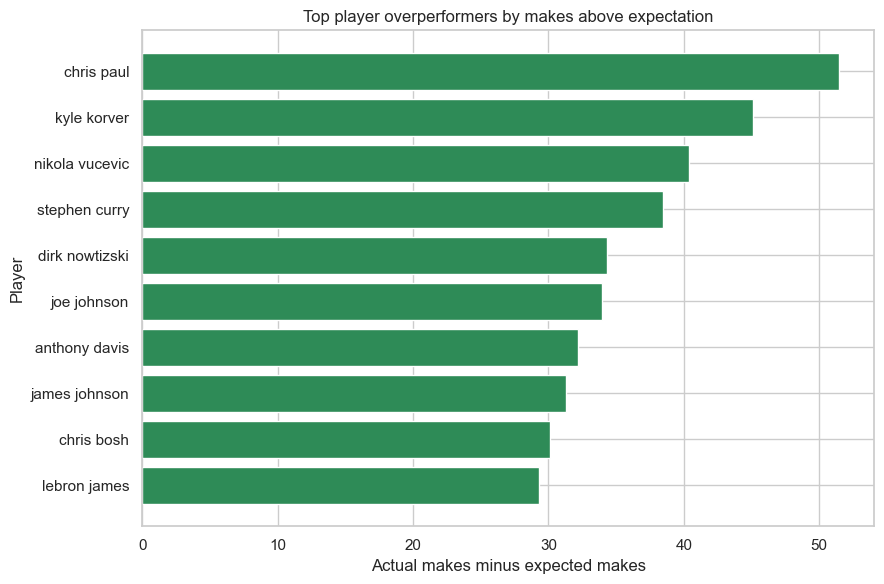

In [7]:
top_players = player_residuals.head(10).sort_values('makes_above_expected')

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_players[PLAYER_NAME_COLUMN], top_players['makes_above_expected'], color='seagreen')
ax.set_title('Top player overperformers by makes above expectation')
ax.set_xlabel('Actual makes minus expected makes')
ax.set_ylabel('Player')
plt.tight_layout()
plt.show()


In [8]:
analysis_handoff = pd.DataFrame({
    'item': [
        'model_used',
        'feature_set',
        'final_row_count',
        'baseline_accuracy',
        'baseline_roc_auc',
        'boosted_accuracy',
        'boosted_roc_auc',
        'note_on_multiseason',
    ],
    'value': [
        'XGBoost classifier with imputed numeric fields and one-hot categorical fields',
        ', '.join(MODEL_COLUMNS),
        len(modeling_shots),
        round(baseline_results['accuracy'], 4),
        round(baseline_results['roc_auc'], 4),
        round(boosted_results['accuracy'], 4),
        round(boosted_results['roc_auc'], 4),
        'Multi-season enriched-table pass still needs local data/processed/shots_enriched.parquet on this machine.',
    ],
})

analysis_handoff


,item,value
0,model_used,XGBoost classifier with imputed numeric fields...
1,feature_set,"FINAL_MARGIN, SHOT_NUMBER, PERIOD, SHOT_CLOCK,..."
2,final_row_count,128069
3,baseline_accuracy,0.6133
4,baseline_roc_auc,0.6347
5,boosted_accuracy,0.6195
6,boosted_roc_auc,0.6436
7,note_on_multiseason,Multi-season enriched-table pass still needs l...


## Notes for Cole

- The boosted model is the stronger RQ1 engine on the current machine because it keeps the shot-context features the project plan cared about most: shot clock, defender distance, dribbles, touch time, and shot distance.
- The residual leaderboard now gives you a clean way to write the shot-quality story: who made more shots than the model expected, by how much, and whether that also shows up at the team level.
- The rank-shift table supports RQ3 by showing which players move most once we compare their raw FG% to a shot-quality-adjusted metric.
- A broader multi-season pass is still possible, but the enriched parquet is not present locally right now, so it is blocked by data availability rather than model design.
